## K-Means Clustering

### Assignment 1 (2 scores):

- Generate a toy dataset having $600$ data points, $200$ points of them following the Gaussian distribution $\mathcal{N}((2, 2), \Sigma)$, $200$ points of them following the Gaussian distribution $\mathcal{N}((8, 3), \Sigma)$, and $200$ points of them following the Gaussian distribution $\mathcal{N}((3, 6), \Sigma)$ where $\Sigma = 
\left(\begin{array}{cc}
    1 & 0 \\
    0 & 1
\end{array}\right)
$.
- Use Numpy only to implement the K-means method for finding three clusters from the toy dataset.
- Train this K-means with EM method.
- Give comments on the effect of intializing centroids randomly to the overall performance of K-means.

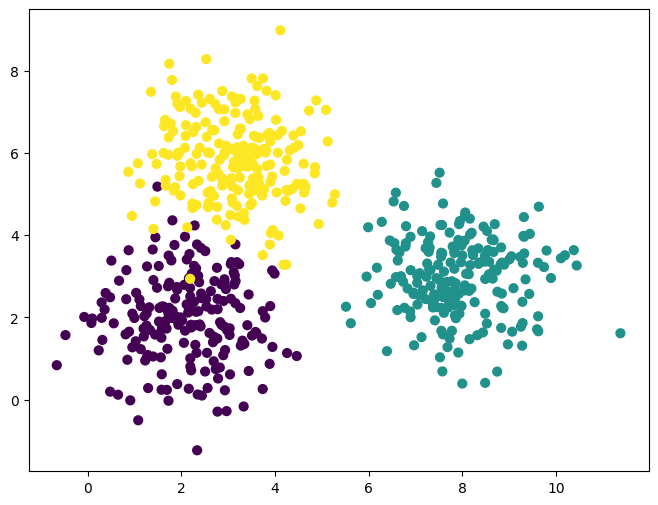

In [21]:
import numpy as np
import matplotlib.pyplot as plt

means = [[2, 2], [8, 3], [3, 6]]
cov = [[1, 0], [0, 1]]
N = 200
X0 = np.random.multivariate_normal(means[0], cov, N)
X1 = np.random.multivariate_normal(means[1], cov, N)
X2 = np.random.multivariate_normal(means[2], cov, N)

X = np.concatenate((X0, X1, X2), axis=0)
Y = np.concatenate((np.zeros((N, 1)), np.ones((N, 1)), 2*np.ones((N, 1))), axis=0)
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=Y, s=40)
plt.show()

In [22]:
from scipy.spatial.distance import cdist

class KMeans:
    def __init__(self, k=2, max_iter=300):
        self.k = k
        self.max_iter = max_iter

    def kmeans_init_centroids(self, X):
        return X[np.random.choice(X.shape[0], self.k, replace=False)]

    def kmeans(self, X, centroids):
        D = cdist(X, centroids)
        return np.argmin(D, axis=1)

    def update_centroids(self, X, clusters):
        centroids = np.zeros((self.k, X.shape[1]))
        for i in range(self.k):
            centroids[i] = np.mean(X[clusters == i], axis=0)
        return centroids

    def check(self, centroids, old_centroids):
        return (set(tuple(c) for c in centroids) == set(tuple(c) for c in old_centroids))
    
    def fit(self, X):
        centroids = self.kmeans_init_centroids(X)
        for _ in range(self.max_iter):
            clusters = self.kmeans(X, centroids)
            old_centroids = centroids
            centroids = self.update_centroids(X, clusters)
            if self.check(centroids, old_centroids):
                break
        return centroids, clusters
    

def plot_kmeans_boundary(X, clusters, centroids, random_state=None):
    
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 500),
        np.linspace(y_min, y_max, 500)
    )
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    D = cdist(grid_points, centroids)
    grid_clusters = np.argmin(D, axis=1)
    grid_clusters = grid_clusters.reshape(xx.shape)
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, grid_clusters, alpha=0.25, cmap="viridis")
    plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap="viridis", s=40)
    plt.scatter(
        centroids[:, 0], centroids[:, 1],
        c="red", marker="X", s=200, label="Centroids"
    )
    random = f"random state {random_state}" if random_state is not None else "final"
    plt.title(f"Visualization of K-Means Clustering ({random})")
    plt.show()

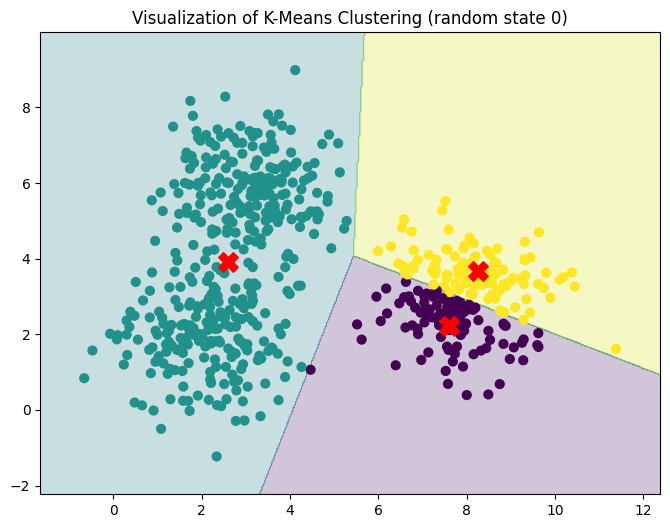

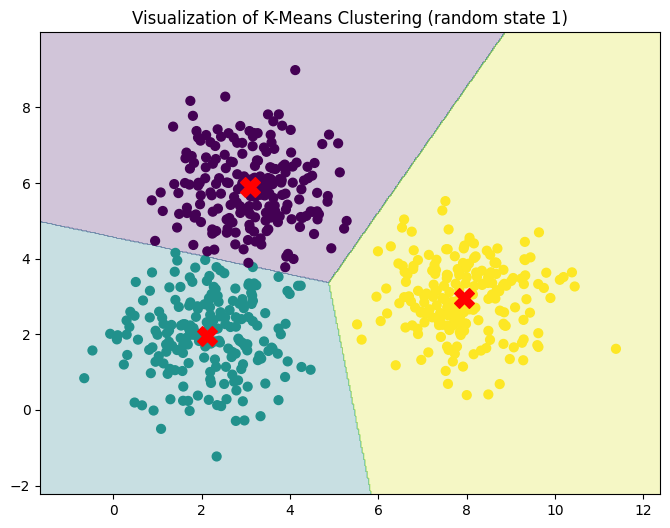

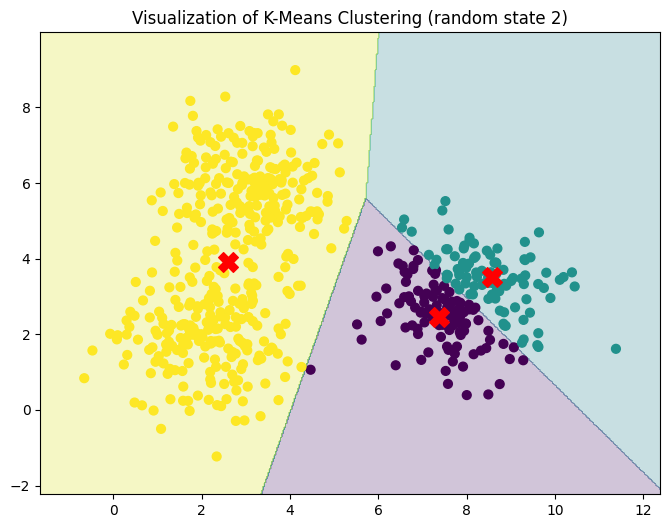

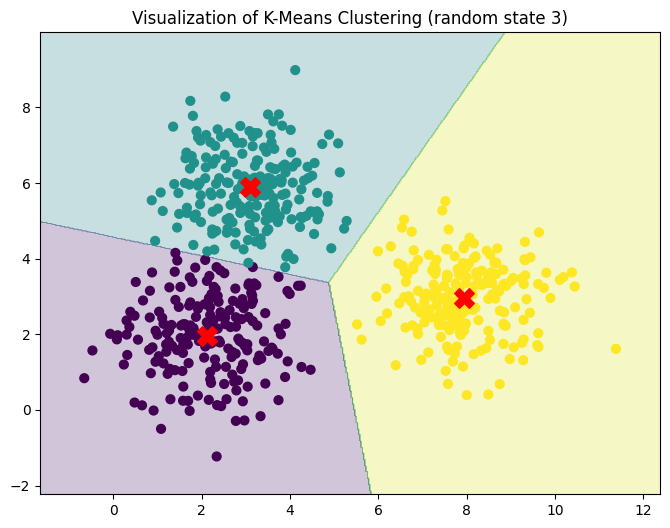

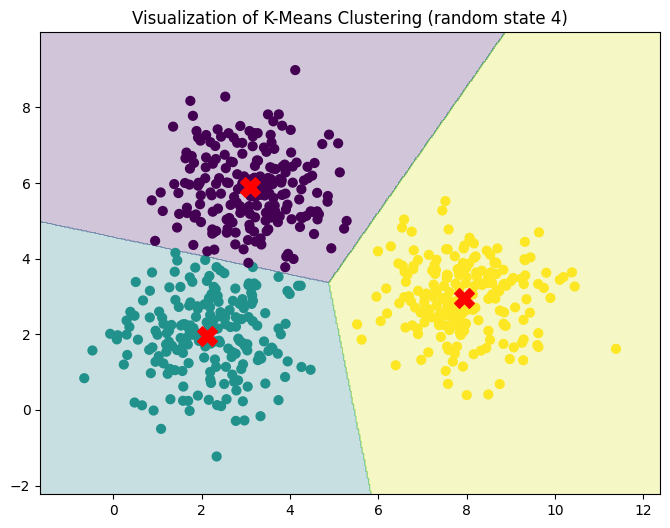

In [23]:
kmeans = KMeans(k=3)
for i in range(5):
    centroids, clusters = kmeans.fit(X)
    plot_kmeans_boundary(X, clusters, centroids, random_state=i)

Hiệu quả và tốc độ hội tụ của K-Means phụ thuộc mạnh vào vị trí các centroid khởi tạo. 

Nếu centroid khởi tạo gần với trung tâm thực của các cụm, thuật toán sẽ hội tụ nhanh và cho chất lượng phân cụm tốt hơn. Ngược lại, các điểm khởi tạo xấu có thể khiến mô hình cần nhiều vòng lặp hơn và dễ rơi vào nghiệm cục bộ, làm giảm performance.

### Assignment 2 (2 scores):
- Generate a toy dataset having $50$ points following the Gaussian distribution $\mathcal{N}((2, 2), \Sigma)$, $20$ points of them following the Gaussian distribution $\mathcal{N}((8, 3), \Sigma)$, and $1000$ points of them following the Gaussian distribution $\mathcal{N}((3, 6), \Sigma)$ where $\Sigma = 
\left(\begin{array}{cc}
    1 & 0 \\
    0 & 1
\end{array}\right)
$.
- Use Numpy only to implement the K-means method for finding three clusters from the toy dataset.
- Train this K-means with EM method.
- Give comments on the effect of different sizes among clusters to the performance of K-means.

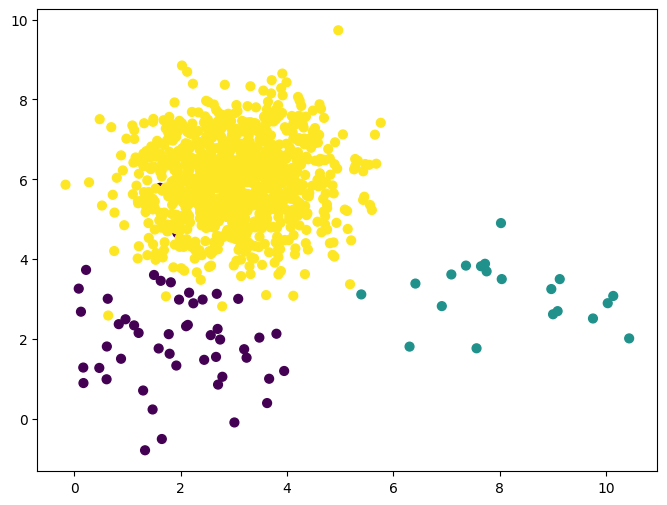

In [24]:
import numpy as np
import matplotlib.pyplot as plt

means = [[2, 2], [8, 3], [3, 6]]
cov = [[1, 0], [0, 1]]

X0 = np.random.multivariate_normal(means[0], cov, 50)
X1 = np.random.multivariate_normal(means[1], cov, 20)
X2 = np.random.multivariate_normal(means[2], cov, 1000)

X = np.concatenate((X0, X1, X2), axis=0)
Y = np.concatenate((np.zeros((50, 1)), np.ones((20, 1)), 2*np.ones((1000, 1))), axis=0)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=Y, s=40)
plt.show()

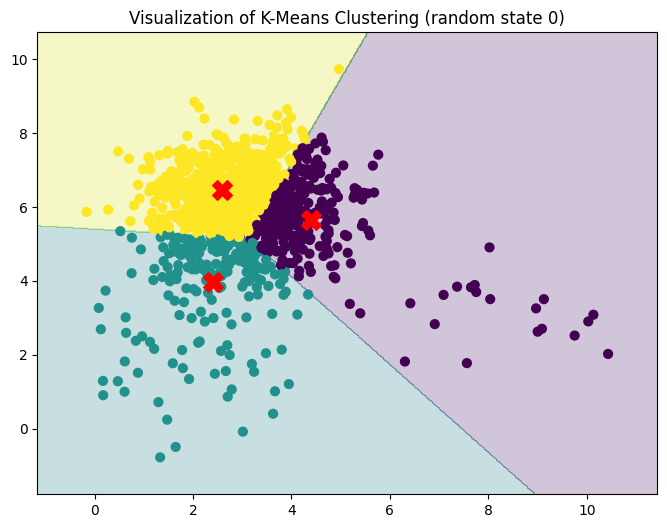

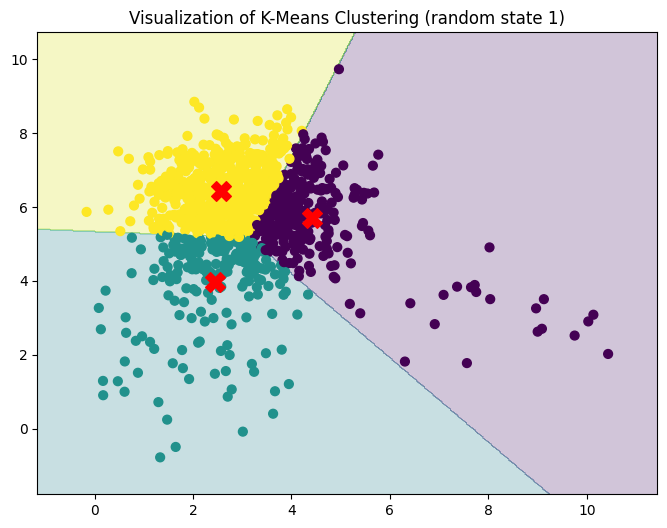

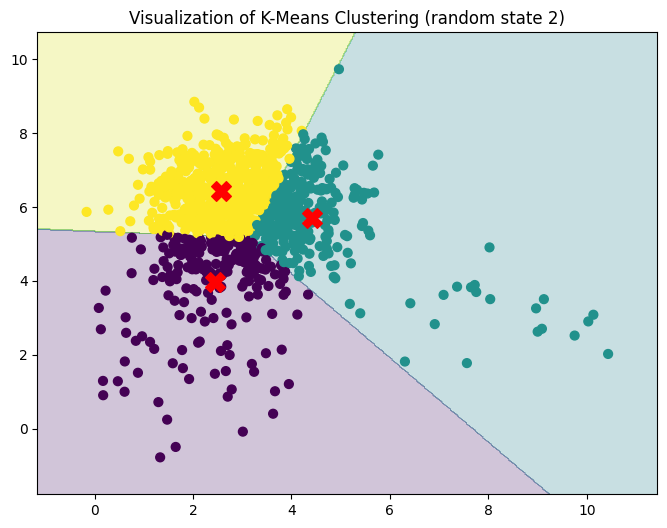

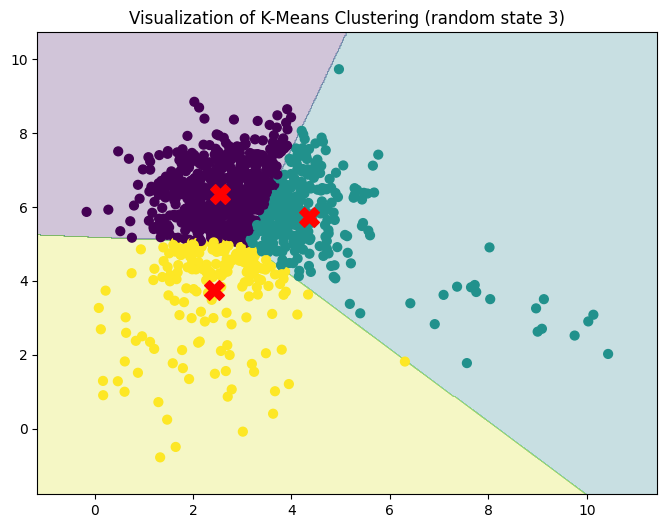

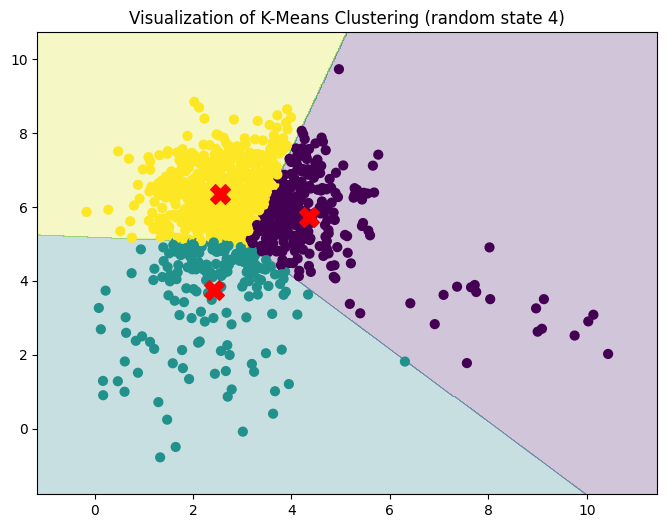

In [25]:
kmeans = KMeans(k=3)
for i in range(5):
    centroids, clusters = kmeans.fit(X)
    plot_kmeans_boundary(X, clusters, centroids, random_state=i)

Nếu centroids khởi tạo ban đầu rơi nhiều vào cụm lớn thì sẽ khó cập nhật lại cụm nhỏ vì khoảng cách giữa chúng với centroids lớn hơn rất nhiều so với các điểm trong cụm lớn, dẫn tới việc các điểm trong cụm nhỏ được mô hình gán sang cụm lớn, kèm thêm số điểm ở cụm lớn rất nhiều nên việc cập nhật lại centroids cho cụm nhỏ cần như không thể

Ví dụ: ta có 2 cụm:
- Cụm lớn:  $C_1$ với centroid $u_1 $ có $n_1$ points
- Cụm nhỏ:  $C_2$  với centroid $u_2 $ có $n_2$ points

Centroids ban đầu khởi tạo $ u_i, u_j $ đều thuộc cụm lớn nên cụm $C_2$ ban đầu được khởi tạo sẽ là 1 trong 2 cụm lớn này (ví dụ $u_i$), đối với cụm được gán là $C_2$ khi cập nhật sẽ tính trung bình các điểm thuộc cụm, nhưng các điểm cụm lớn chiếm ưu thế nên centroids vẫn sẽ không thể nào thoát khỏi cụm lớn, ví dụ $n_i$ là số điểm thuộc cụm lớn được gán $C_2$
Khi cập nhật trọng số: $$ u_i^{\text{update}} = \frac{\lVert x - u_i \rVert^{2}}{n_i + n_2} (x \in \hat{C_2})$$ 
Do $n_i >> n_2$ nên centroid vẫn chỉ cập nhật quanh các điểm cụm lớn không thoát ra được



### Assignment 3 (2 scores):

- Generate a toy dataset having $600$ data points, $200$ points of them following the Gaussian distribution $\mathcal{N}((2, 2), \Sigma_1)$, $200$ points of them following the Gaussian distribution $\mathcal{N}((8, 3), \Sigma_1)$, and $200$ points of them following the Gaussian distribution $\mathcal{N}((3, 6), \Sigma_2)$ where 

$$
    \Sigma_1 = 
    \left(\begin{array}{cc}
        1 & 0 \\
        0 & 1
    \end{array}\right)
$$ 

and

$$
\Sigma_2 = 
    \left(\begin{array}{cc}
        10 & 0 \\
        0 & 1
    \end{array}\right)
$$.

- Use Numpy only to implement the K-means method for finding three clusters from the toy dataset.
- Train this K-means with EM method.
- Give comments on the effect of distribution $\mathcal{N}((3, 6), \Sigma_2)$ to the performance of K-means.

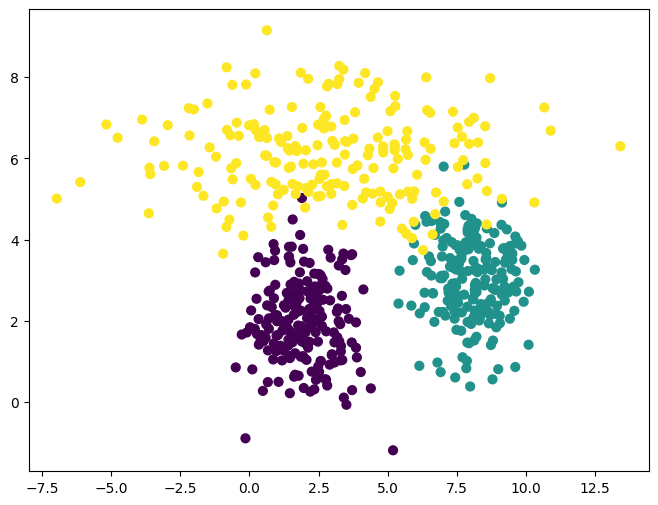

In [26]:
import numpy as np
import matplotlib.pyplot as plt

means = [[2, 2], [8, 3], [3, 6]]
cov1 = [[1, 0], [0, 1]]
cov2 = [[10, 0], [0, 1]]
N = 200
X0 = np.random.multivariate_normal(means[0], cov1, N)
X1 = np.random.multivariate_normal(means[1], cov1, N)
X2 = np.random.multivariate_normal(means[2], cov2, N)

X = np.concatenate((X0, X1, X2), axis=0)
Y = np.concatenate((np.zeros((N, 1)), np.ones((N, 1)), 2*np.ones((N, 1))), axis=0)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=Y, s=40)
plt.show()

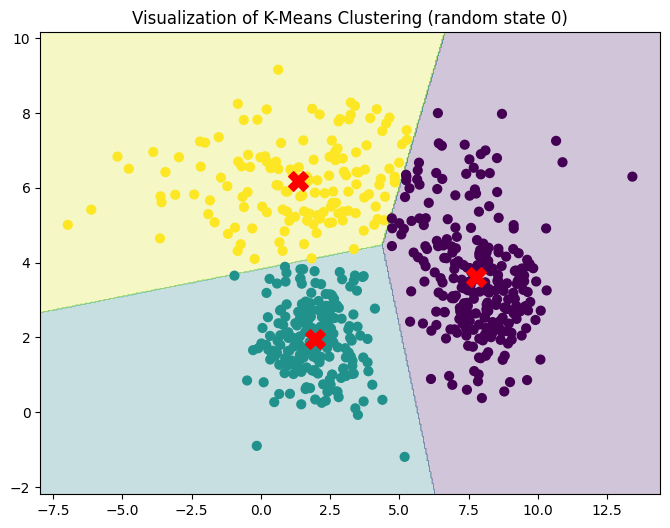

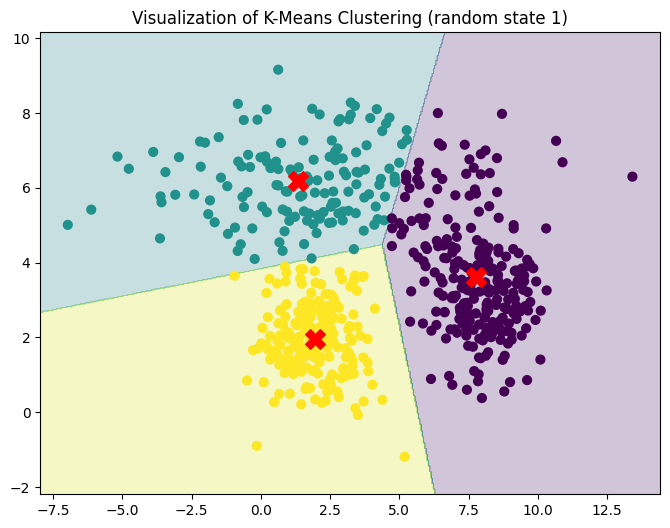

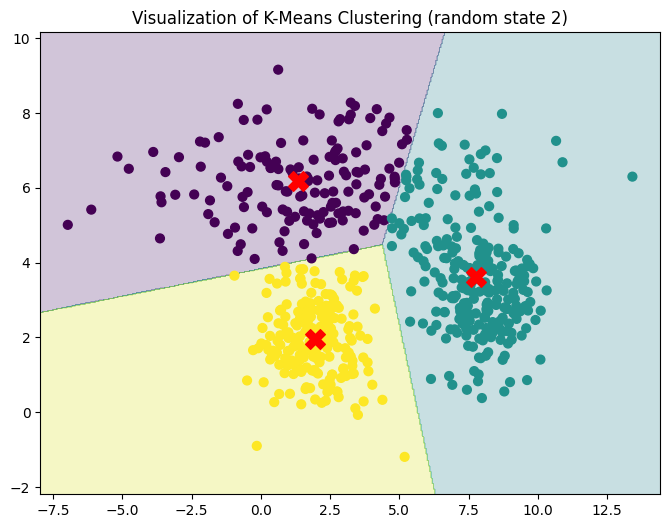

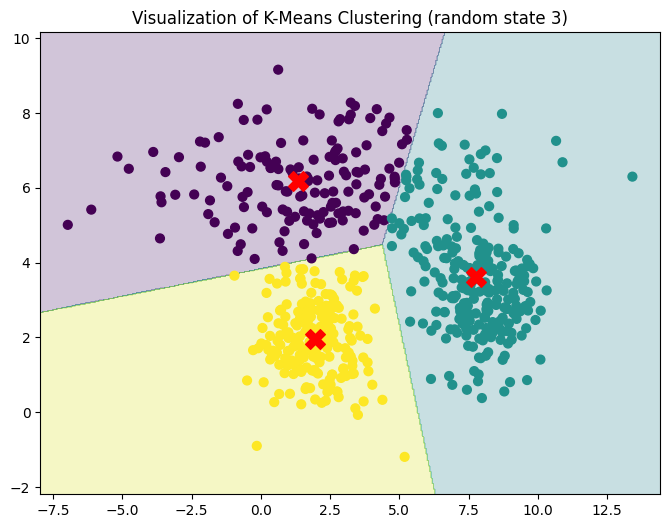

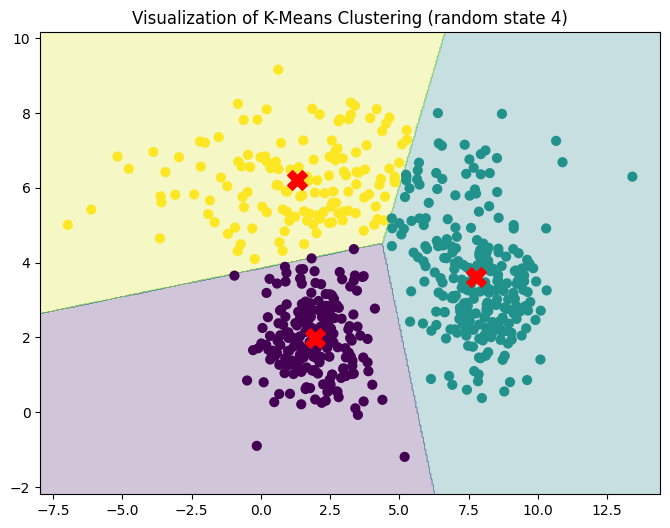

In [27]:
kmeans = KMeans(k=3)
for i in range(5):
    centroids, clusters = kmeans.fit(X)
    plot_kmeans_boundary(X, clusters, centroids, random_state=i)

KMeans dùng khoảng cách Euclid để đo độ gần giữa các điểm, nên khi thuật toán chạy tốt thì các điểm trong từng cụm phải nằm gần centroid của cụm đó nhất. Vì khoảng cách Euclid giả định các cụm có dạng hình tròn (hay tròn đều theo mọi hướng), nên khi dữ liệu bị lệch scale theo một chiều, cụm không còn hình tròn mà bị kéo dài ra. Điều này làm một số điểm ở phía bị kéo dài trở nên xa centroid thật của cụm, thậm chí còn gần centroid của cụm khác hơn. Kết quả là các điểm đó dễ bị gán nhầm cụm, khiến quá trình cập nhật centroids bị lệch và KMeans không thể tìm được phân cụm tối ưu.

## Gaussian Mixture Model

### Assignment 1 (2 scores):
- Use Numpy only to implement the Gaussian Mixture Model.
- Train Gaussian Mixture Model with EM method.

### Assignment 2 (2 scores):

Use the Gaussian Mixture Model to filter out background of a given image.